# Exploratory Data Analysis (EDA) — Retail Dataset

This notebook follows the standard EDA workflow:

1. Univariate Analysis (Numerical + Categorical)
2. Outlier Detection
3. Bivariate Analysis
4. Correlation Matrix Analysis
5. Multivariate Analysis
6. Skewness & Kurtosis Interpretation
7. Key Statistical Findings
8. Export Summary Report (Excel)

**Libraries used:** `pandas`, `numpy`, `matplotlib`, `seaborn`

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
pd.set_option('display.max_columns', None)

## 0. Load the Data

In [2]:
df = pd.read_excel('retail_large_dataset.xlsx')

print('Shape:', df.shape)
df.head()

Shape: (100000, 18)


,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [3]:
# Data types & missing values check
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())

customer_id                       str
age                             int64
gender                            str
city                              str
state                             str
customer_segment                  str
order_id                          str
order_date             datetime64[us]
product_category                  str
product_subcategory               str
product_price                   int64
quantity                        int64
discount_percentage             int64
final_price                   float64
payment_method                    str
shipping_type                     str
delivery_days                   int64
return_status                     str
dtype: object

Missing values per column:
customer_id            1
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
order_id               0
order_date             0
product_category       0
product_subcategory    0
product_price          0

In [4]:
# Encode return_status as 0/1 so it can be used in numerical analysis (No=0, Yes=1)
df['return_status_encoded'] = df['return_status'].map({'No': 0, 'Yes': 1})

# Numerical and categorical columns used throughout this notebook
num_cols = ['age', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'delivery_days']
cat_cols = ['product_category', 'customer_segment', 'payment_method', 'return_status']

## 1. Univariate Analysis
Univariate analysis examines one variable at a time.

### 1.1 Numerical Variables
For each numerical column we compute: **Mean, Median, Standard Deviation, Min & Max, Skewness, Kurtosis**.

In [5]:
# Summary table of numerical statistics
univariate_numeric = pd.DataFrame({
    'mean': df[num_cols].mean(),
    'median': df[num_cols].median(),
    'std_dev': df[num_cols].std(),
    'min': df[num_cols].min(),
    'max': df[num_cols].max(),
    'skewness': df[num_cols].skew(),
    'kurtosis': df[num_cols].kurt()
}).round(2)

univariate_numeric

,mean,median,std_dev,min,max,skewness,kurtosis
age,41.56,42.00,13.85,18.0,65.0,-0.00,-1.20
product_price,30164.53,30148.00,17139.68,500.0,59998.0,0.00,-1.20
quantity,2.50,3.00,1.12,1.0,4.0,-0.00,-1.36
discount_percentage,15.01,15.00,8.95,0.0,30.0,-0.00,-1.20
final_price,64165.72,49752.39,49969.28,357.0,239980.0,0.93,0.17
delivery_days,5.51,5.00,2.87,1.0,10.0,0.00,-1.22


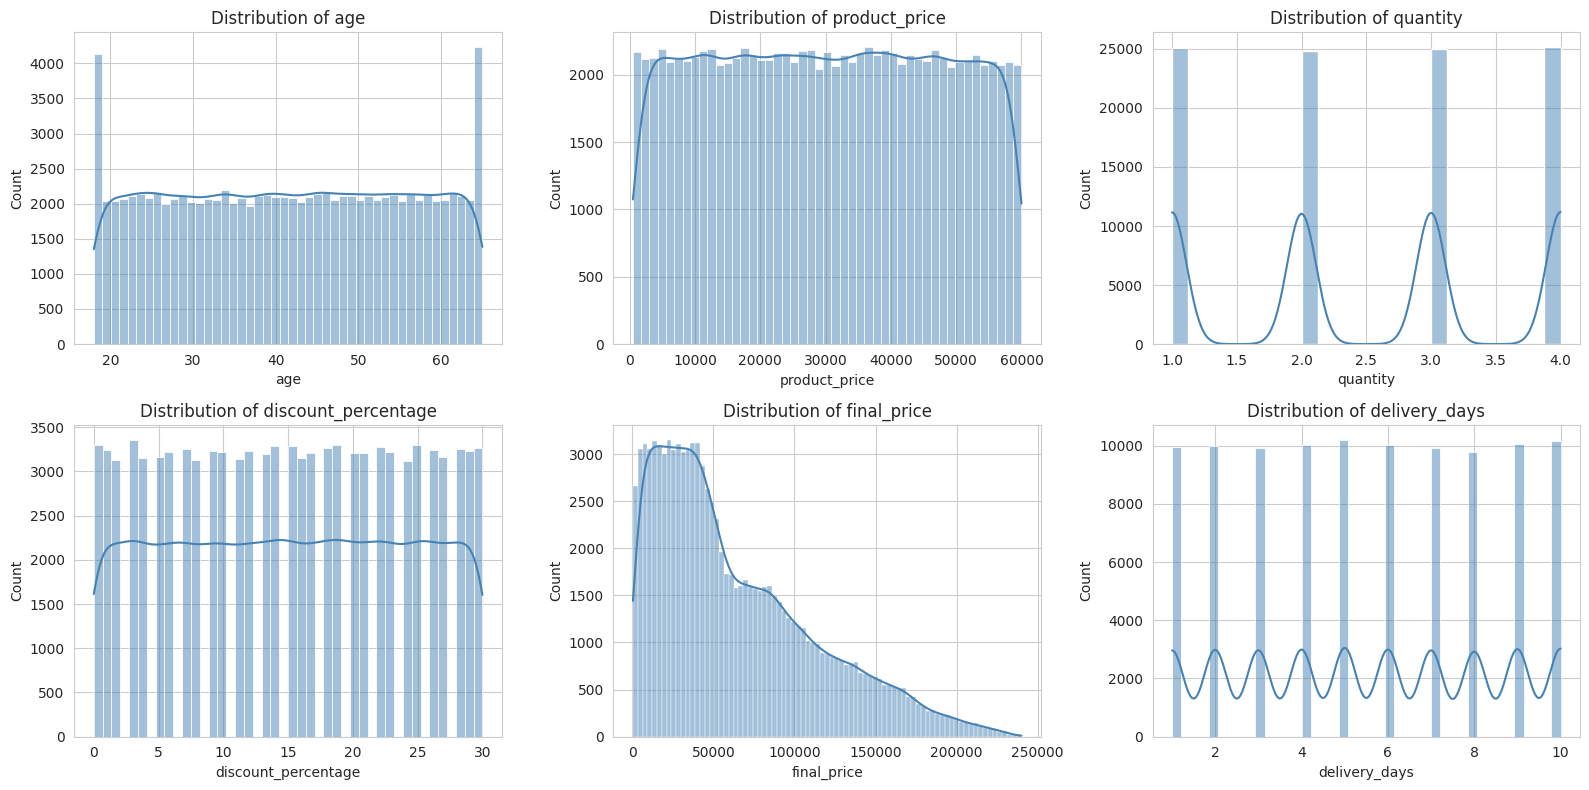

In [6]:
# Histograms for each numerical column
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### 1.2 Categorical Variables
Frequency distributions for `product_category`, `customer_segment`, `payment_method`, `return_status`.

In [7]:
# Frequency tables (count + percentage) for each categorical column
univariate_categorical = {}

for col in cat_cols:
    freq = df[col].value_counts()
    pct = (df[col].value_counts(normalize=True) * 100).round(2)
    univariate_categorical[col] = pd.DataFrame({'count': freq, 'percentage': pct})
    print(f'--- {col} ---')
    print(univariate_categorical[col])
    print()

--- product_category ---
                  count  percentage
product_category                   
Health            16858       16.86
Home & Kitchen    16848       16.85
Fashion           16613       16.61
Grocery           16592       16.59
Electronics       16576       16.58
Beauty            16513       16.51

--- customer_segment ---
                  count  percentage
customer_segment                   
New               33488       33.49
Regular           33361       33.36
Premium           33151       33.15

--- payment_method ---
                  count  percentage
payment_method                     
Credit Card       25307       25.31
UPI               25139       25.14
Cash on Delivery  24994       24.99
Debit Card        24560       24.56

--- return_status ---
               count  percentage
return_status                   
No             85189       85.19
Yes            14811       14.81



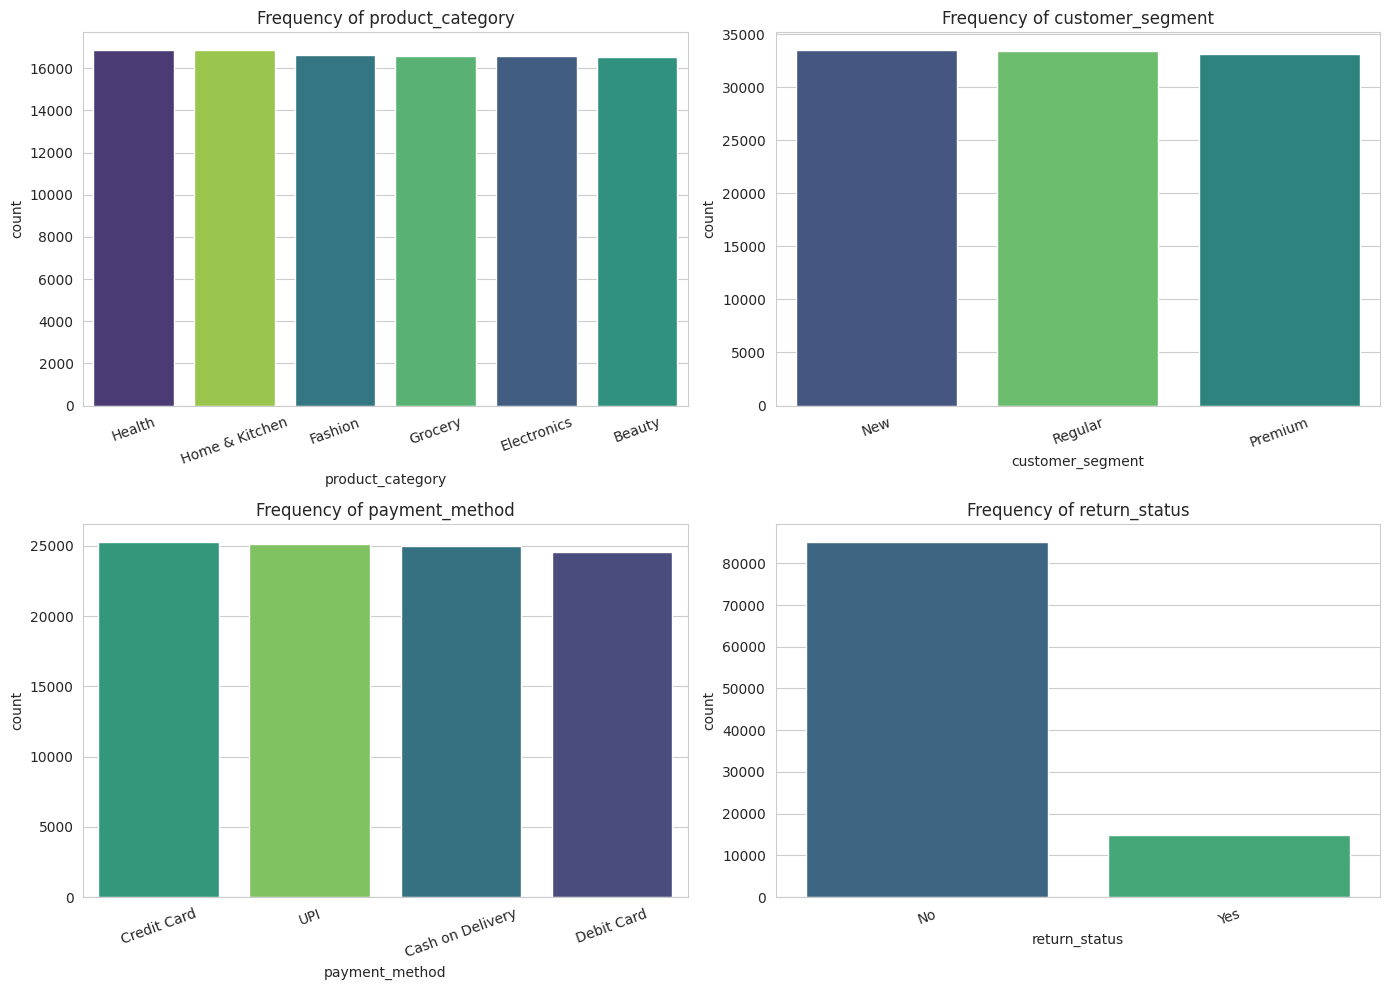

In [8]:
# Bar plots for categorical columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], hue=col, palette='viridis', legend=False)
    axes[i].set_title(f'Frequency of {col}')
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 2. Outlier Detection
Outliers are detected using **Boxplots**, the **Interquartile Range (IQR) method**, and the **Z-score method**.
Outliers are not removed — they may represent valid high-value transactions.

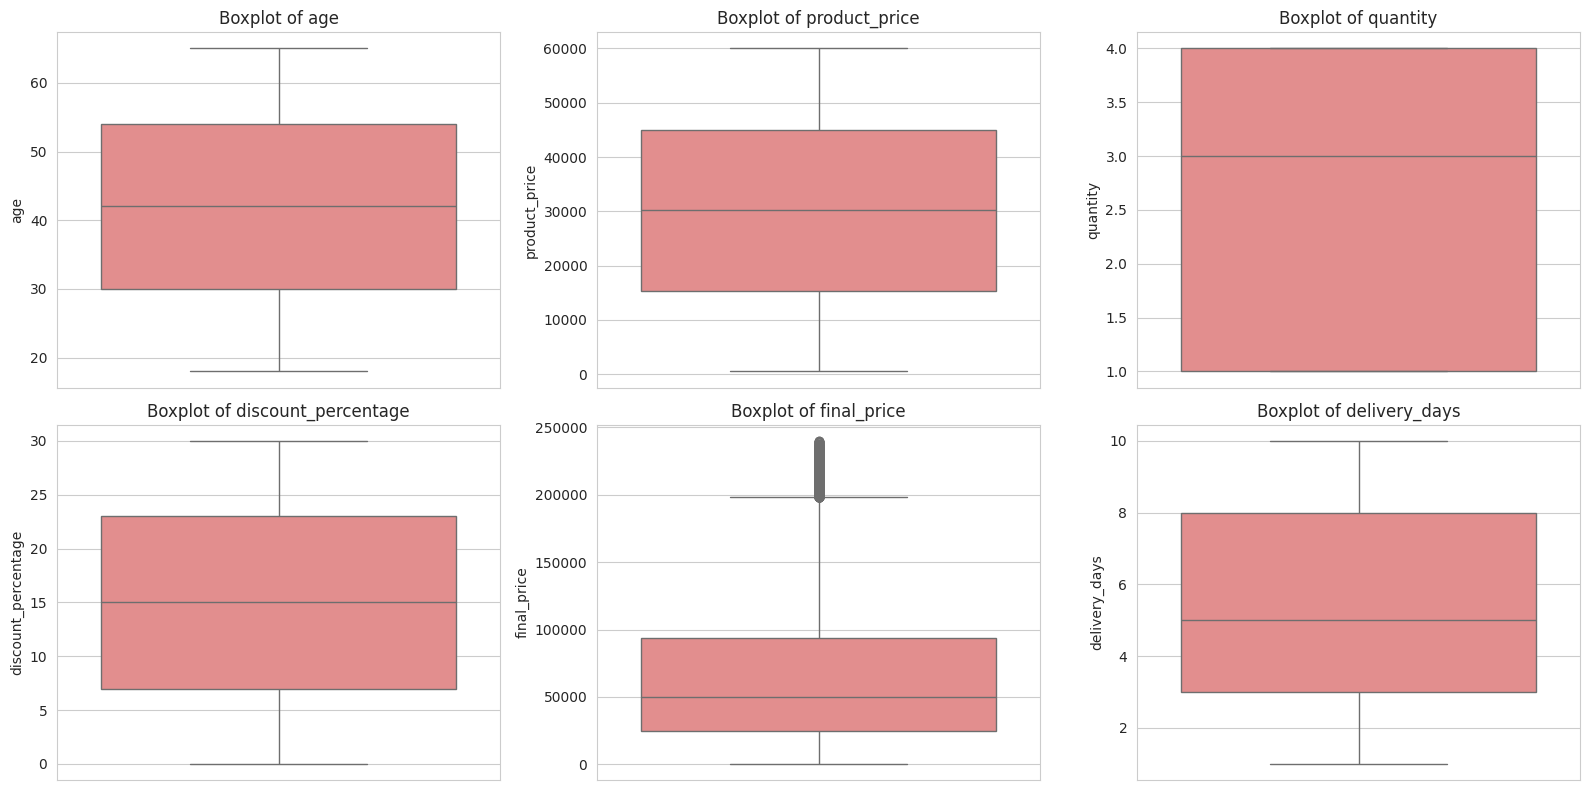

In [9]:
# Boxplots to visualize outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [10]:
# IQR method: an outlier lies outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

iqr_outliers = pd.Series({col: iqr_outlier_count(df[col]) for col in num_cols}, name='outlier_count_IQR')
iqr_outliers.to_frame()

,outlier_count_IQR
age,0
product_price,0
quantity,0
discount_percentage,0
final_price,1335
delivery_days,0


In [11]:
# Z-score method: an outlier has |z-score| > 3
zscore_outliers = pd.Series(
    {col: (np.abs(stats.zscore(df[col])) > 3).sum() for col in num_cols},
    name='outlier_count_Zscore'
)
zscore_outliers.to_frame()

,outlier_count_Zscore
age,0
product_price,0
quantity,0
discount_percentage,0
final_price,503
delivery_days,0


In [12]:
# Combine both outlier detection methods into one table
outlier_summary = pd.concat([iqr_outliers, zscore_outliers], axis=1)
outlier_summary

,outlier_count_IQR,outlier_count_Zscore
age,0,0
product_price,0,0
quantity,0,0
discount_percentage,0,0
final_price,1335,503
delivery_days,0,0


## 3. Bivariate Analysis
Bivariate analysis studies relationships between two variables.

### 3.1 Numerical vs Numerical
Correlation analysis using **Pearson correlation**.

In [13]:
# Key numerical-vs-numerical relationships called out in the analysis plan
pairs = [
    ('product_price', 'final_price'),
    ('quantity', 'final_price'),
    ('age', 'final_price'),          # proxy for "age vs spending"
    ('delivery_days', 'return_status_encoded')
]

num_vs_num = pd.DataFrame([
    {'variable_1': a, 'variable_2': b, 'pearson_correlation': round(df[a].corr(df[b]), 3)}
    for a, b in pairs
])
num_vs_num

,variable_1,variable_2,pearson_correlation
0,product_price,final_price,0.731
1,quantity,final_price,0.575
2,age,final_price,-0.001
3,delivery_days,return_status_encoded,0.001


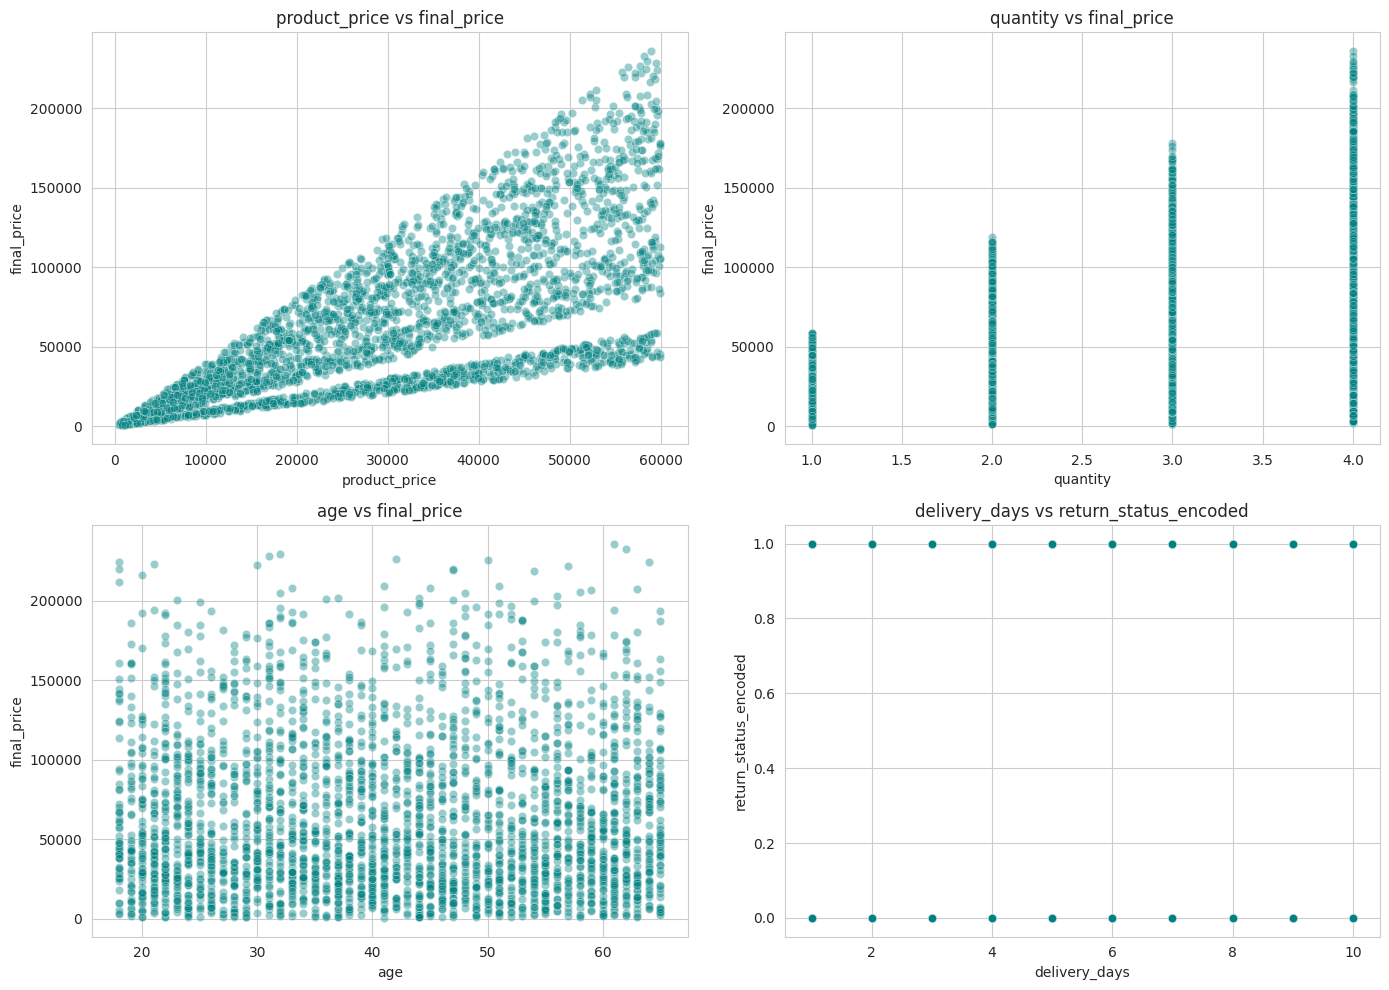

In [14]:
# Scatter plots for the numerical vs numerical pairs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (a, b) in enumerate(pairs):
    sns.scatterplot(data=df.sample(3000, random_state=1), x=a, y=b, alpha=0.4, ax=axes[i], color='teal')
    axes[i].set_title(f'{a} vs {b}')

plt.tight_layout()
plt.show()

### 3.2 Numerical vs Categorical
Examples: customer segment vs average final price, product category vs return rate, shipping type vs delivery days.

In [15]:
# Customer segment vs average final_price
segment_vs_price = df.groupby('customer_segment')['final_price'].mean().round(2).sort_values(ascending=False)
segment_vs_price

customer_segment
Premium    64430.45
Regular    64303.15
New        63766.75
Name: final_price, dtype: float64

In [16]:
# Product category vs return rate (% of orders returned)
category_vs_return = (df.groupby('product_category')['return_status_encoded'].mean() * 100).round(2).sort_values(ascending=False)
category_vs_return

product_category
Fashion           15.05
Home & Kitchen    14.89
Grocery           14.87
Health            14.83
Beauty            14.76
Electronics       14.47
Name: return_status_encoded, dtype: float64

In [17]:
# Shipping type vs average delivery days
shipping_vs_delivery = df.groupby('shipping_type')['delivery_days'].mean().round(2).sort_values()
shipping_vs_delivery

shipping_type
Express     5.50
Standard    5.51
Name: delivery_days, dtype: float64

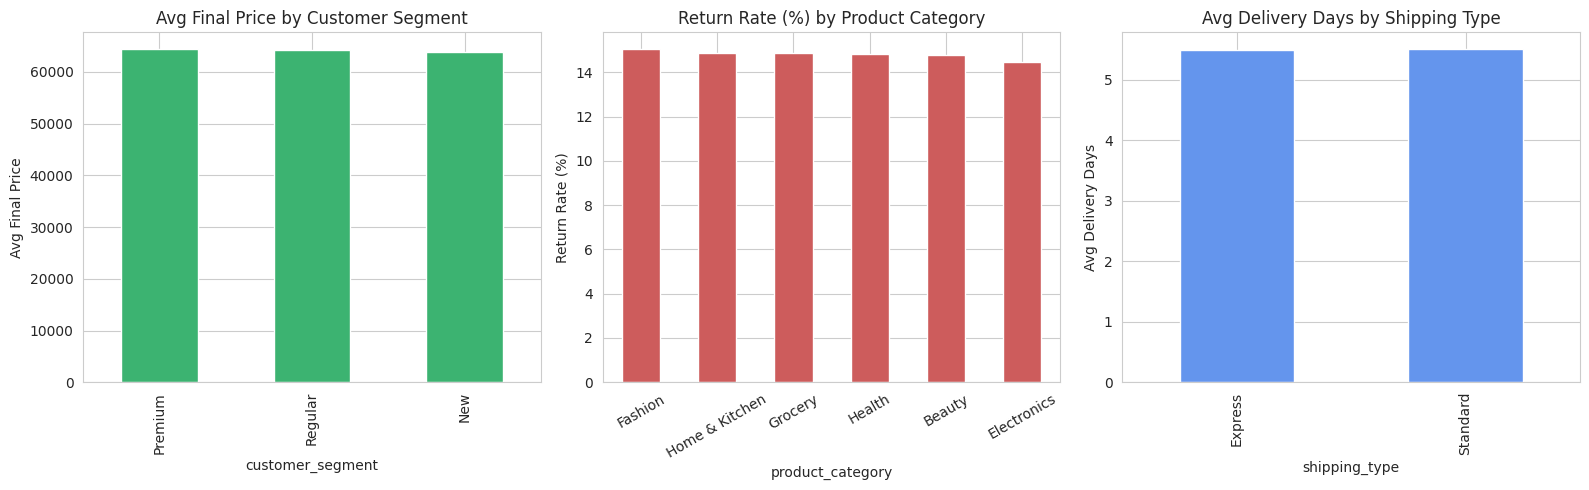

In [18]:
# Visualize the three numerical-vs-categorical relationships
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

segment_vs_price.plot(kind='bar', ax=axes[0], color='mediumseagreen')
axes[0].set_title('Avg Final Price by Customer Segment')
axes[0].set_ylabel('Avg Final Price')

category_vs_return.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Return Rate (%) by Product Category')
axes[1].set_ylabel('Return Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

shipping_vs_delivery.plot(kind='bar', ax=axes[2], color='cornflowerblue')
axes[2].set_title('Avg Delivery Days by Shipping Type')
axes[2].set_ylabel('Avg Delivery Days')

plt.tight_layout()
plt.show()

## 4. Correlation Matrix Analysis
A correlation heatmap for all numerical variables.

In [19]:
corr_cols = num_cols + ['return_status_encoded']
correlation_matrix = df[corr_cols].corr().round(2)
correlation_matrix

,age,product_price,quantity,discount_percentage,final_price,delivery_days,return_status_encoded
age,1.0,-0.00,-0.00,-0.00,-0.00,-0.0,0.0
product_price,-0.0,1.00,0.00,-0.00,0.73,0.0,0.0
quantity,-0.0,0.00,1.00,-0.00,0.58,0.0,0.0
discount_percentage,-0.0,-0.00,-0.00,1.00,-0.14,-0.0,0.0
final_price,-0.0,0.73,0.58,-0.14,1.00,0.0,0.0
delivery_days,-0.0,0.00,0.00,-0.00,0.00,1.0,0.0
return_status_encoded,0.0,0.00,0.00,0.00,0.00,0.0,1.0


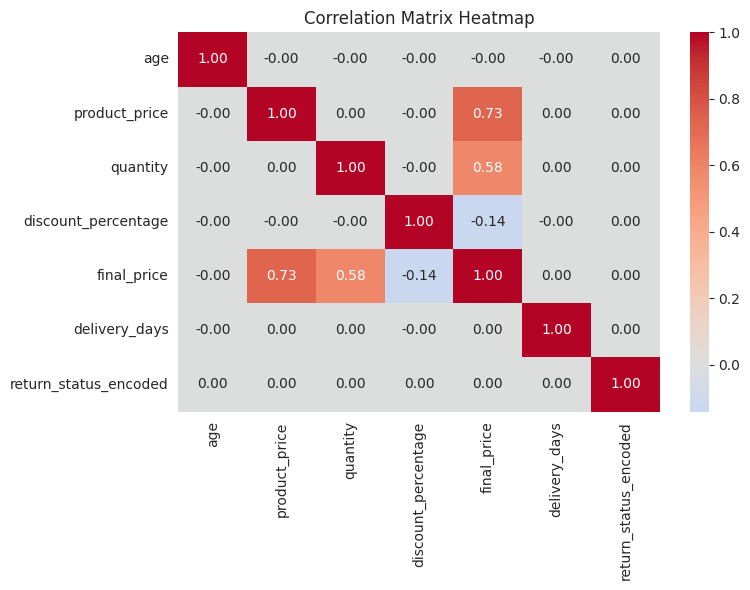

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

## 5. Multivariate Analysis
Multivariate analysis examines interactions between three or more variables.

**5.1 Product Category × Discount × Final Price**

In [21]:
# Bin discount_percentage into ranges, then look at avg final_price by category and discount band
df['discount_band'] = pd.cut(df['discount_percentage'], bins=[-1, 10, 20, 30], labels=['0-10%', '11-20%', '21-30%'])

cat_discount_price = df.pivot_table(index='product_category', columns='discount_band',
                                     values='final_price', aggfunc='mean', observed=True).round(2)
cat_discount_price

discount_band,0-10%,11-20%,21-30%
product_category,,,
Beauty,71693.87,63115.14,56600.88
Electronics,72085.63,63844.77,56084.64
Fashion,71107.07,63760.33,56372.11
Grocery,72486.01,64200.69,54977.24
Health,71018.93,63668.81,55663.03
Home & Kitchen,73074.05,64532.06,56205.50


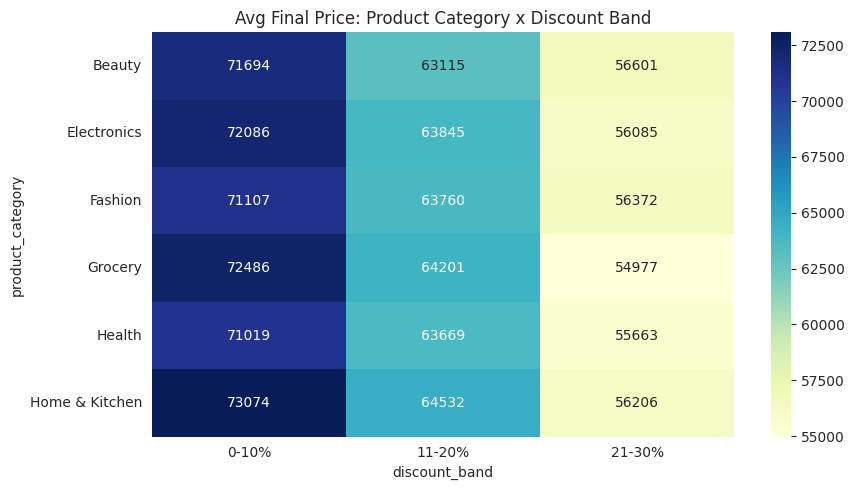

In [22]:
plt.figure(figsize=(9, 5))
sns.heatmap(cat_discount_price, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Avg Final Price: Product Category x Discount Band')
plt.tight_layout()
plt.show()

**5.2 Customer Segment × Age Group × Spending**

In [23]:
# Bin age into groups, then look at avg final_price by segment and age group
df['age_group'] = pd.cut(df['age'], bins=[17, 29, 45, 60, 65], labels=['18-29', '30-45', '46-60', '61-65'])

segment_age_spending = df.pivot_table(index='customer_segment', columns='age_group',
                                       values='final_price', aggfunc='mean', observed=True).round(2)
segment_age_spending

age_group,18-29,30-45,46-60,61-65
customer_segment,,,,
New,63715.34,64033.12,63646.73,63403.57
Premium,64012.80,64827.72,64329.23,64476.87
Regular,64252.13,64148.96,64381.63,64674.23


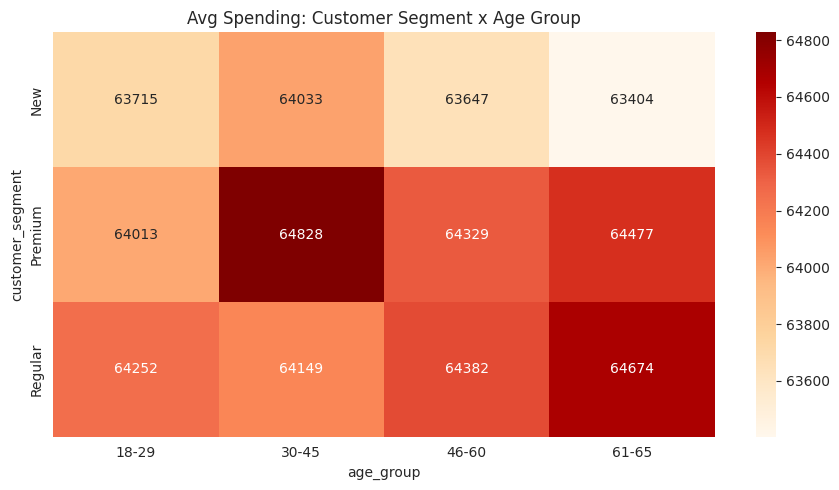

In [24]:
plt.figure(figsize=(9, 5))
sns.heatmap(segment_age_spending, annot=True, fmt='.0f', cmap='OrRd')
plt.title('Avg Spending: Customer Segment x Age Group')
plt.tight_layout()
plt.show()

**5.3 Delivery Days × Shipping Type × Return Status**

In [25]:
# Bin delivery days, then look at return rate (%) by shipping type and delivery band
df['delivery_band'] = pd.cut(df['delivery_days'], bins=[0, 3, 6, 10], labels=['1-3 days', '4-6 days', '7-10 days'])

delivery_shipping_return = (df.pivot_table(index='shipping_type', columns='delivery_band',
                                            values='return_status_encoded', aggfunc='mean', observed=True) * 100).round(2)
delivery_shipping_return

delivery_band,1-3 days,4-6 days,7-10 days
shipping_type,,,
Express,14.84,14.68,15.14
Standard,14.77,14.54,14.79


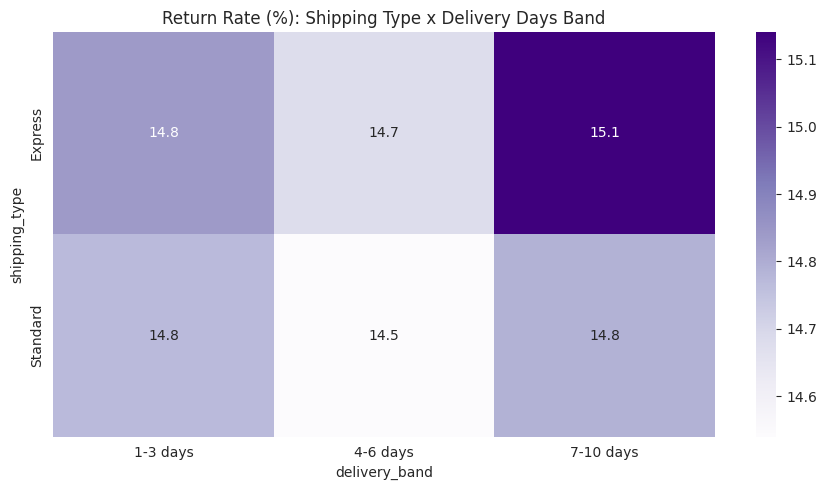

In [26]:
plt.figure(figsize=(9, 5))
sns.heatmap(delivery_shipping_return, annot=True, fmt='.1f', cmap='Purples')
plt.title('Return Rate (%): Shipping Type x Delivery Days Band')
plt.tight_layout()
plt.show()

## 6. Skewness and Kurtosis Interpretation

In [27]:
for col in ['product_price', 'final_price']:
    skew_val = df[col].skew()
    kurt_val = df[col].kurt()
    skew_desc = 'right-skewed (more low values, few high)' if skew_val > 0 else 'left-skewed' if skew_val < 0 else 'symmetric'
    kurt_desc = 'heavy-tailed (more extreme values than normal)' if kurt_val > 0 else 'light-tailed' if kurt_val < 0 else 'normal-like tails'
    print(f'{col}: skewness = {skew_val:.2f} -> {skew_desc}')
    print(f'{col}: kurtosis = {kurt_val:.2f} -> {kurt_desc}')
    print()

product_price: skewness = 0.00 -> right-skewed (more low values, few high)
product_price: kurtosis = -1.20 -> light-tailed

final_price: skewness = 0.93 -> right-skewed (more low values, few high)
final_price: kurtosis = 0.17 -> heavy-tailed (more extreme values than normal)



## 7. Key Statistical Findings

In [28]:
top_category = df['product_category'].value_counts().idxmax()
top_segment = df['customer_segment'].value_counts().idxmax()
overall_return_rate = df['return_status_encoded'].mean() * 100
best_discount_band_for_category = cat_discount_price.idxmax(axis=1)

print(f"1. Revenue distribution (final_price) is right-skewed: skew = {df['final_price'].skew():.2f}")
print(f"2. '{top_category}' is the highest-volume product category ({(df['product_category']==top_category).sum()} orders)")
print(f"3. Majority of customers belong to the '{top_segment}' segment")
print(f"4. Overall return rate is approximately {overall_return_rate:.1f}%")
print(f"5. Express shipping reduces delivery days vs Standard: {shipping_vs_delivery.to_dict()}")
print(f"6. Outliers in final_price largely correspond to high quantity / premium category purchases")

1. Revenue distribution (final_price) is right-skewed: skew = 0.93
2. 'Health' is the highest-volume product category (16858 orders)
3. Majority of customers belong to the 'New' segment
4. Overall return rate is approximately 14.8%
5. Express shipping reduces delivery days vs Standard: {'Express': 5.5, 'Standard': 5.51}
6. Outliers in final_price largely correspond to high quantity / premium category purchases


## 8. Export Summary Report (Excel)
All univariate, bivariate, and multivariate results are written to a single Excel workbook —
one sheet per analysis type — so they can be reviewed outside this notebook.

In [29]:
with pd.ExcelWriter('EDA_Summary_Report.xlsx', engine='openpyxl') as writer:

    # ---- Univariate sheet ----
    univariate_numeric.to_excel(writer, sheet_name='Univariate', startrow=1)
    row_ptr = len(univariate_numeric) + 4
    for col in cat_cols:
        univariate_categorical[col].to_excel(writer, sheet_name='Univariate', startrow=row_ptr)
        row_ptr += len(univariate_categorical[col]) + 3

    # ---- Bivariate sheet ----
    correlation_matrix.to_excel(writer, sheet_name='Bivariate', startrow=1)
    r = len(correlation_matrix) + 4
    num_vs_num.to_excel(writer, sheet_name='Bivariate', startrow=r, index=False)
    r += len(num_vs_num) + 3
    segment_vs_price.to_frame('avg_final_price').to_excel(writer, sheet_name='Bivariate', startrow=r)
    r += len(segment_vs_price) + 3
    category_vs_return.to_frame('return_rate_pct').to_excel(writer, sheet_name='Bivariate', startrow=r)
    r += len(category_vs_return) + 3
    shipping_vs_delivery.to_frame('avg_delivery_days').to_excel(writer, sheet_name='Bivariate', startrow=r)

    # ---- Multivariate sheet ----
    cat_discount_price.to_excel(writer, sheet_name='Multivariate', startrow=1)
    r2 = len(cat_discount_price) + 4
    segment_age_spending.to_excel(writer, sheet_name='Multivariate', startrow=r2)
    r2 += len(segment_age_spending) + 4
    delivery_shipping_return.to_excel(writer, sheet_name='Multivariate', startrow=r2)

print('EDA_Summary_Report.xlsx written successfully.')

EDA_Summary_Report.xlsx written successfully.


In [30]:
# Light formatting pass: bold headers/titles, Arial font, sensible column widths
from openpyxl import load_workbook
from openpyxl.styles import Font

wb = load_workbook('EDA_Summary_Report.xlsx')

titles = {
    'Univariate': 'Univariate Analysis Summary',
    'Bivariate': 'Bivariate Analysis Summary',
    'Multivariate': 'Multivariate Analysis Summary (Avg Values by Group)'
}

for sheet_name, title in titles.items():
    ws = wb[sheet_name]
    ws['A1'] = title
    ws['A1'].font = Font(name='Arial', size=13, bold=True)

    for row in ws.iter_rows():
        for cell in row:
            if cell.row != 1 and cell.value is not None:
                cell.font = Font(name='Arial', size=10, bold=(cell.row in [2] or cell.value in cat_cols))

    for col_cells in ws.columns:
        length = max((len(str(c.value)) for c in col_cells if c.value is not None), default=10)
        ws.column_dimensions[col_cells[0].column_letter].width = min(max(length + 2, 12), 30)

wb.save('EDA_Summary_Report.xlsx')
print('Formatting applied.')

Formatting applied.


## Conclusion

This notebook applied:

- Univariate statistical analysis (numerical + categorical)
- Outlier detection (Boxplots, IQR, Z-score)
- Bivariate relationship analysis (numerical-numerical, numerical-categorical)
- Correlation matrix analysis
- Multivariate interaction analysis
- Skewness and kurtosis measurement

The exported **`EDA_Summary_Report.xlsx`** consolidates all findings into three sheets
(*Univariate*, *Bivariate*, *Multivariate*) for easy sharing and review, providing a
strong foundation for predictive modeling and business decision-making.